In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../src')


In [3]:
# img_name = 'HAND1_Brachyury_mid_+'
# channel_names = ['HAND1', 'BMP4', 'T', 'Hoechst']

img_name = '20260717T120225_pA_Activin_D4_48hr_W0001'
channel_names = ['Sox17', 'Activin', 'FoxA2', 'Hoechst']

cell_df = pd.read_csv(f'../data/training/{img_name}.csv', index_col=0)
print(cell_df.shape)
cell_df.head(3)


(8193, 22)


,centroid_y,centroid_x,area,perimeter,perimeter_crofton,eccentricity,solidity,extent,major_axis_length,minor_axis_length,...,circularity,aspect_ratio,Sox17_mean,Activin_mean,FoxA2_mean,Hoechst_mean,Sox17+,Activin+,FoxA2+,Hoechst+
cell_id,,,,,,,,,,,,,,,,,,,,,
1,18.220315,16.409156,699.0,117.254834,113.846070,0.879298,0.867246,0.588384,44.792304,21.333307,...,0.677721,2.099642,322.367668,117.566524,230.658083,824.291845,False,False,False,True
2,7.408333,36.075000,120.0,40.384776,40.968686,0.626714,0.960000,0.714286,14.306811,11.148574,...,0.898436,1.283286,249.166667,117.691667,167.083333,623.425000,False,False,False,True
3,8.741176,72.747059,340.0,69.798990,68.855109,0.402561,0.960452,0.809524,21.975670,20.116375,...,0.901190,1.092427,168.947059,116.614706,155.764706,1017.235294,False,False,False,True


## Intrinsic model: does a cell's shape and its signaling/fate state travel together?

BMP/nodal activation here is a light-triggered, spatially patterned perturbation. Once a
cell has (or hasn't) been driven into a given transcriptional/signaling state, does *that
state alone* explain how the cell looks -- independent of what's going on around it? This
notebook treats every cell as an isolated unit (no spatial information, no neighbors).

Which columns are the input and which are the target is fully configurable in the
`EXPERIMENTS` cell below -- e.g. morphology -> IF, IF -> morphology, or leave-one-out within
a single modality (predict one IF marker from the *other* IF markers, and same for
morphology) to test inter-feature redundancy/correlation. Compare against `extrinsic.ipynb`,
which asks the non-cell-autonomous version of these same questions using a cell's
*neighbors'* features instead of its own.

`HAND1_mean`/`BMP4_mean`/`T_mean` are the IF readouts; `Hoechst_mean` (nuclear counterstain,
not a signaling readout) is excluded by default -- flip `EXCLUDE_HOECHST` to include it.


In [ ]:
from sklearn.model_selection import train_test_split

from tools.morphology import (
    MORPHOLOGY_COLS,
    marker_cols,
    zero_out_negative_if,
    set_seed,
    leave_one_out_configs,
    TabularFeatureMapper,
    train_feature_mapper,
    plot_loss_curves,
    plot_pred_vs_actual,
    r2_table,
    plot_feature_importance_by_target,
    permutation_importance_mlp,
    plot_correlation_heatmap,
    plot_experiment_comparison,
    top_correlated_pairs,
)

SEED = 0
set_seed(SEED)

EXCLUDE_HOECHST = True
# If True, sets `{marker}_mean` to 0 for every cell where `{marker}+` is False --
# treats IF-negative as true zero signal rather than whatever background/baseline
# intensity the mean happened to measure. No-op on the saved CSV -- this only ever
# alters the in-memory `cell_df` here.
ZERO_OUT_NEGATIVE_IF = False

morphology_cols = MORPHOLOGY_COLS
if_cols = marker_cols(cell_df, 'mean')
if EXCLUDE_HOECHST:
    if_cols = [c for c in if_cols if c != 'Hoechst_mean']

cell_df = zero_out_negative_if(cell_df, if_cols, zero_out=ZERO_OUT_NEGATIVE_IF)

print(f'{len(morphology_cols)} morphology features:', morphology_cols)
print(f'{len(if_cols)} immunofluorescence features:', if_cols)

In [5]:
# random train/val/test split at the CELL level -- intrinsic predictions don't
# depend on spatial structure, so an ordinary i.i.d. split is appropriate here
# (contrast with extrinsic.ipynb, where the split has to respect the graph).
train_df, test_df = train_test_split(cell_df, test_size=0.15, random_state=SEED)
train_df, val_df = train_test_split(train_df, test_size=0.15 / 0.85, random_state=SEED)

print(f'train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}')


train: 5735  val: 1229  test: 1229


In [6]:
# TabularFeatureMapper fits a scaler per x_cols/y_cols group on train_df ONLY (see
# make_scaler in tools/modeling.py) -- train_df/val_df/test_df stay in original units.
print('raw feature scales (train_df, original units):')
display(train_df[morphology_cols + if_cols].describe().T[['mean', 'std', 'min', 'max']])


raw feature scales (train_df, original units):


,mean,std,min,max
area,439.333915,170.990341,101.000000,1752.000000
perimeter_crofton,80.991827,16.251781,37.731808,168.587132
circularity,0.816531,0.068013,0.553000,0.979413
eccentricity,0.664873,0.140115,0.130092,0.941378
Sox17_mean,272.196193,479.770995,161.072893,23266.034843
Activin_mean,120.505632,27.096359,113.098701,627.824845
FoxA2_mean,182.767081,297.658262,140.431169,16987.726027


In [7]:
def run_tabular_experiment(
    name, x_cols, y_cols,
    hidden_dims=(128, 64), dropout=0.1,
    epochs=150, lr=1e-3, batch_size=512, patience=15,
    n_repeats=5,
):
    """Full pipeline for one (x_cols -> y_cols) configuration: train a
    `TabularFeatureMapper`, evaluate on the test set (original + standardized units),
    and run permutation importance -- prints/plots everything and returns a dict with
    the model, history, and importance table for later reuse."""
    print(f'\n=== {name}: {x_cols} -> {y_cols} ===')

    model = TabularFeatureMapper(x_cols=x_cols, y_cols=y_cols, hidden_dims=hidden_dims, dropout=dropout)
    history = train_feature_mapper(
        model, train_df, val_df,
        epochs=epochs, lr=lr, batch_size=batch_size, patience=patience, desc=name,
    )
    plot_loss_curves({name: history}, title=name)
    plt.show()

    pred_test = model.predict_df(test_df)
    true_test = test_df[y_cols]
    r2 = r2_table(true_test, pred_test)
    display(r2)
    plot_pred_vs_actual(true_test, pred_test, title=f'{name}, test set')
    plt.show()

    true_scaled = model.scale_y(test_df)
    pred_scaled = model.predict_df(test_df, scaled=True)
    plot_pred_vs_actual(true_scaled, pred_scaled, title=f'{name}, test set, standardized units')
    plt.show()

    imp = permutation_importance_mlp(model, test_df, n_repeats=n_repeats, seed=SEED)
    plot_feature_importance_by_target(imp, title=f'{name}: which input features predict each target?')
    plt.show()

    return dict(model=model, history=history, r2=r2, importance=imp)

In [10]:
# Edit this to change what predicts what -- any list of column names works for either
# side, not just morphology_cols/if_cols wholesale. Comment out an entry to skip running it.
# Any extra kwarg (e.g. hidden_dims, dropout, epochs) gets forwarded to run_tabular_experiment,
# so the same x_cols -> y_cols pair can be run at multiple architectures for direct comparison
# in the heatmap below -- e.g. `_deep` here vs. the default (128, 64) MLP.
EXPERIMENTS = {
    'morph_to_if': dict(x_cols=morphology_cols, y_cols=if_cols),
    'if_to_morph': dict(x_cols=if_cols, y_cols=morphology_cols),
    **leave_one_out_configs(if_cols, prefix='other_if_to'),
    **leave_one_out_configs(morphology_cols, prefix='other_morph_to'),
}


=== morph_to_if: ['area', 'perimeter_crofton', 'circularity', 'eccentricity'] -> ['Sox17_mean', 'Activin_mean', 'FoxA2_mean'] ===


morph_to_if:   0%|          | 0/150 [00:00<?, ?it/s]

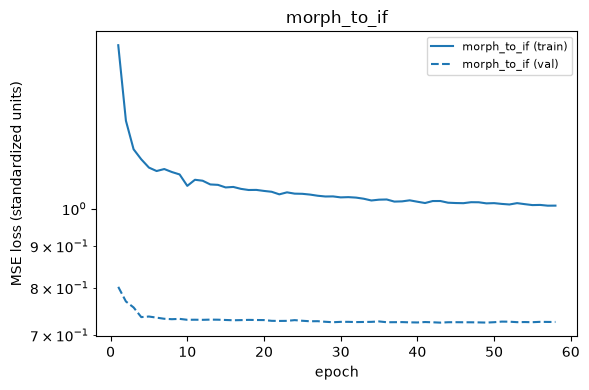

,R2,MAE
feature,,
Sox17_mean,-0.017711,46.174387
Activin_mean,-0.008663,6.907725
FoxA2_mean,-0.232717,24.661765


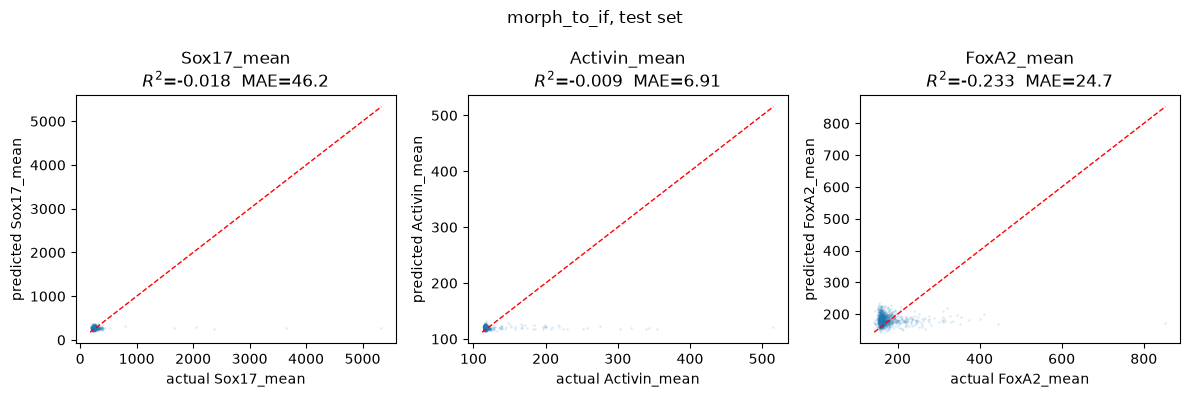

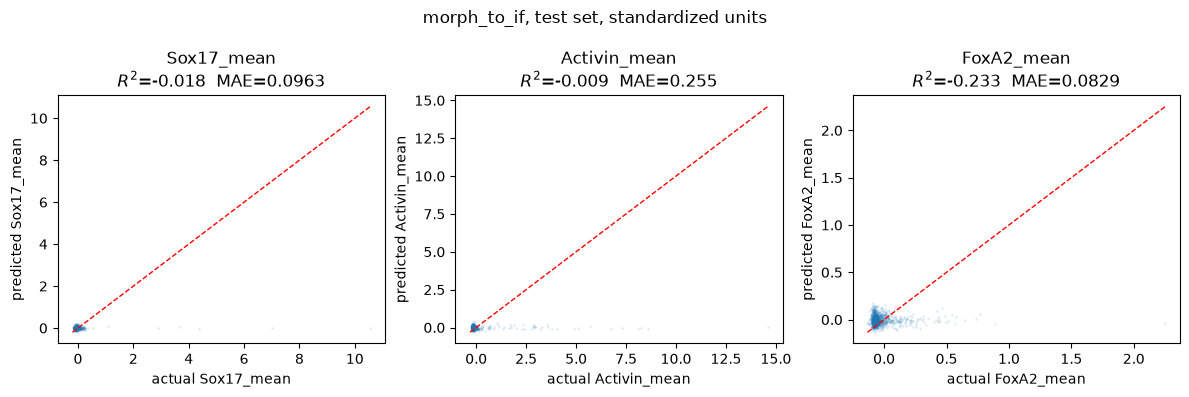

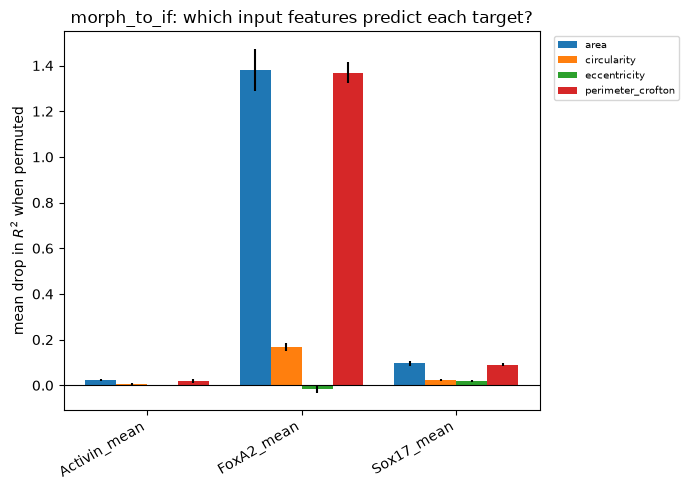


=== if_to_morph: ['Sox17_mean', 'Activin_mean', 'FoxA2_mean'] -> ['area', 'perimeter_crofton', 'circularity', 'eccentricity'] ===


if_to_morph:   0%|          | 0/150 [00:00<?, ?it/s]

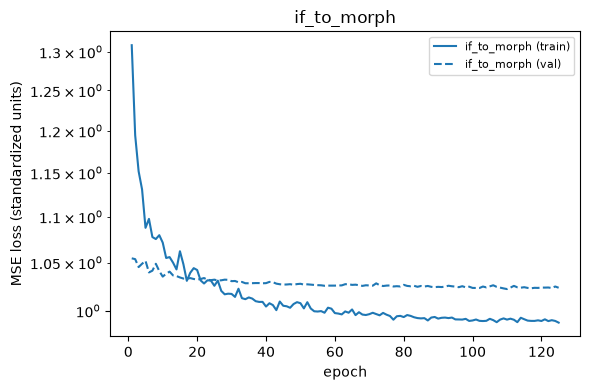

,R2,MAE
feature,,
area,0.011709,130.147035
perimeter_crofton,0.007597,12.681377
circularity,-0.003372,0.054879
eccentricity,-0.000773,0.111960


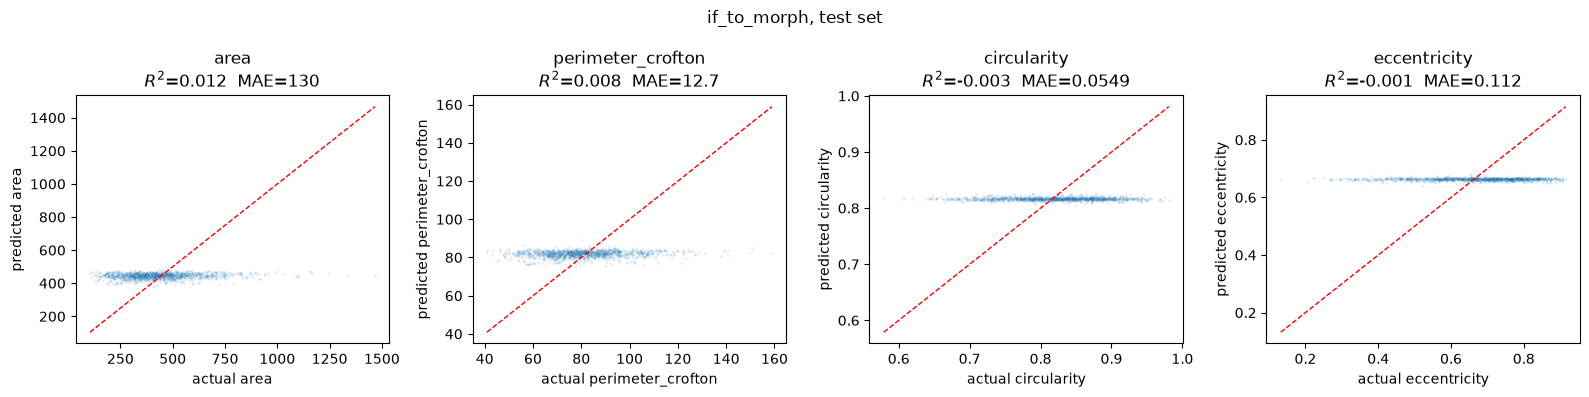

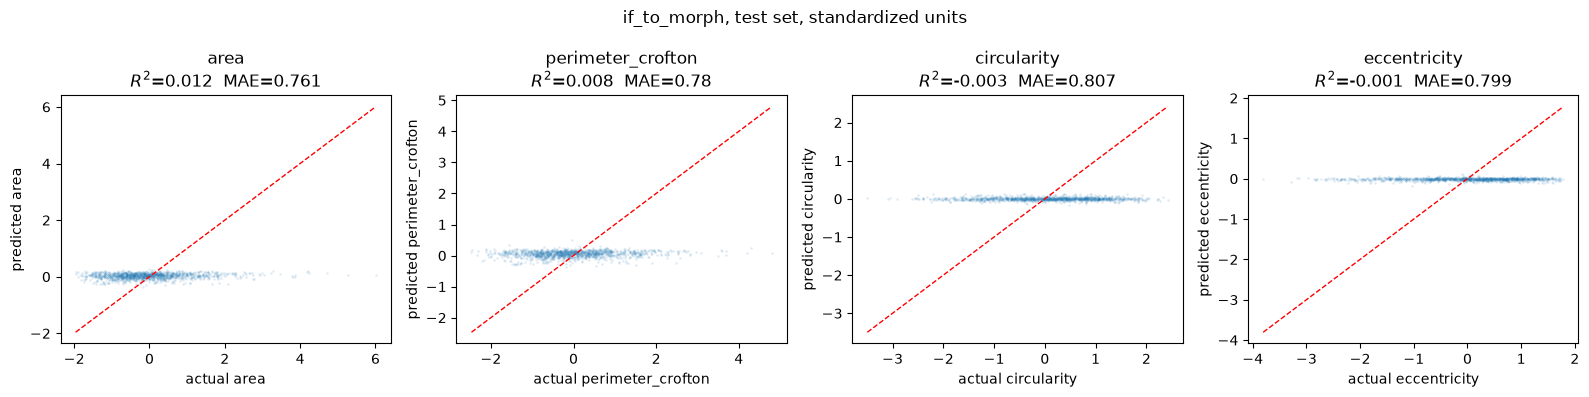

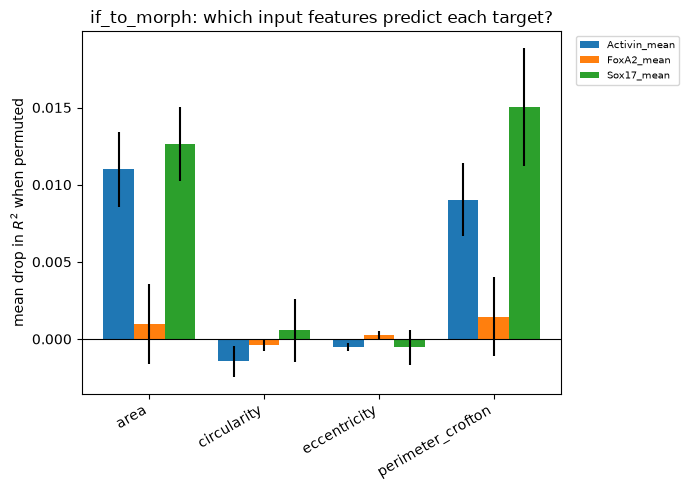


=== other_if_to_Sox17_mean: ['Activin_mean', 'FoxA2_mean'] -> ['Sox17_mean'] ===


other_if_to_Sox17_mean:   0%|          | 0/150 [00:00<?, ?it/s]

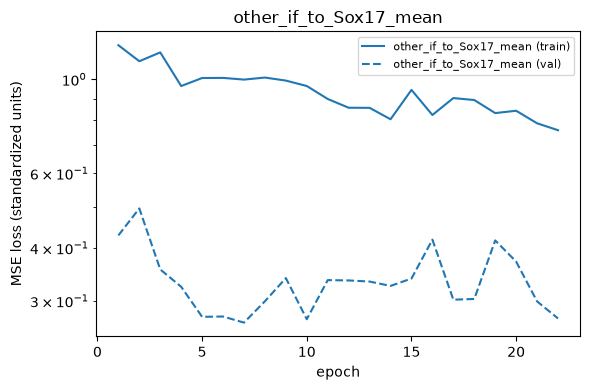

,R2,MAE
feature,,
Sox17_mean,-0.026878,68.901841


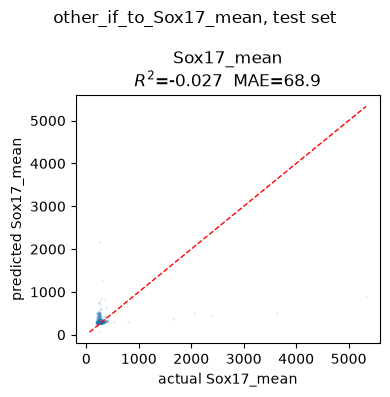

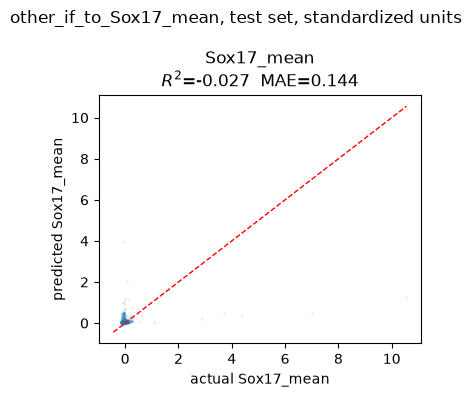

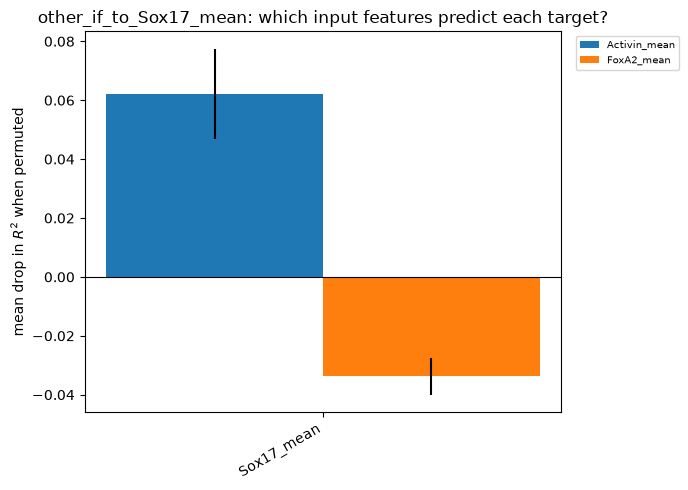


=== other_if_to_Activin_mean: ['Sox17_mean', 'FoxA2_mean'] -> ['Activin_mean'] ===


other_if_to_Activin_mean:   0%|          | 0/150 [00:00<?, ?it/s]

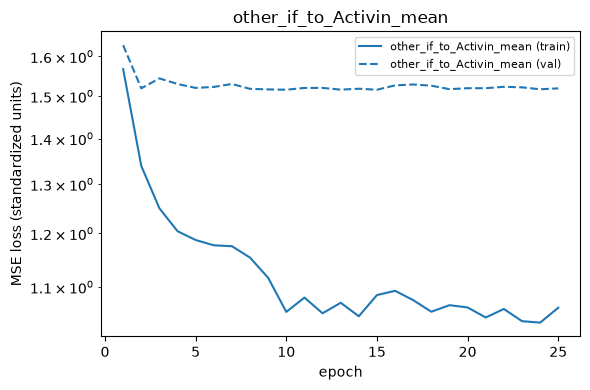

,R2,MAE
feature,,
Activin_mean,0.003689,6.84302


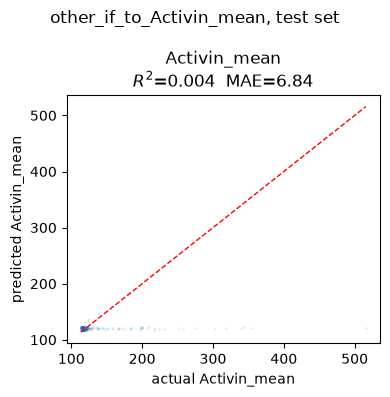

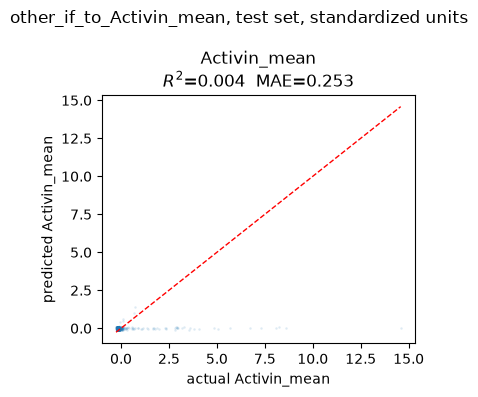

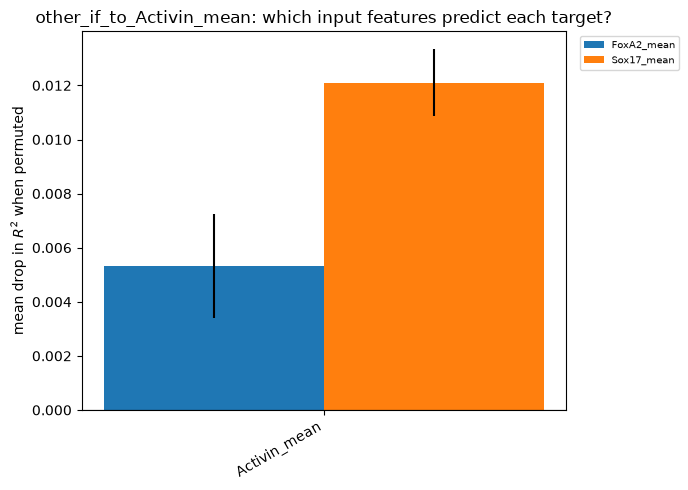


=== other_if_to_FoxA2_mean: ['Sox17_mean', 'Activin_mean'] -> ['FoxA2_mean'] ===


other_if_to_FoxA2_mean:   0%|          | 0/150 [00:00<?, ?it/s]

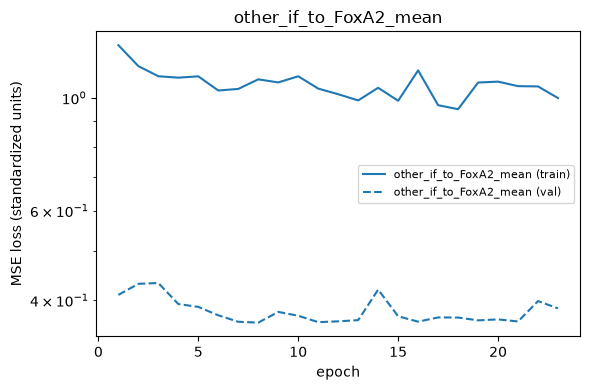

,R2,MAE
feature,,
FoxA2_mean,-0.064986,21.353765


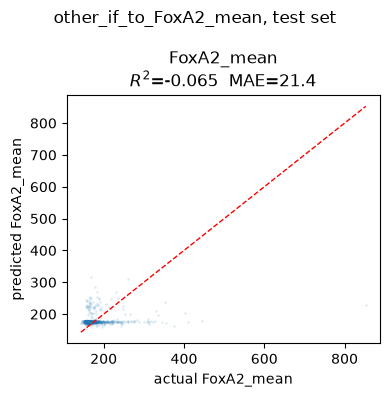

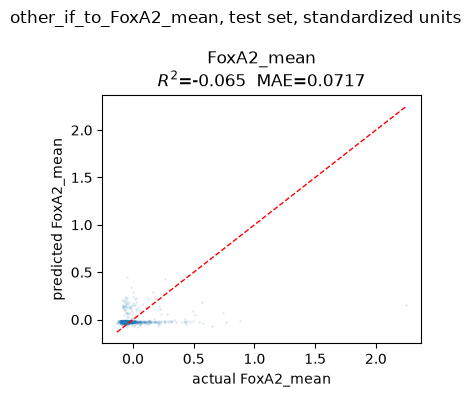

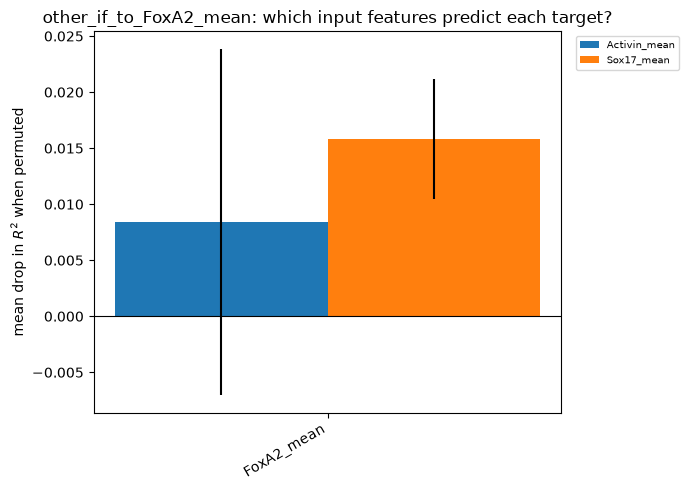


=== other_morph_to_area: ['perimeter_crofton', 'circularity', 'eccentricity'] -> ['area'] ===


other_morph_to_area:   0%|          | 0/150 [00:00<?, ?it/s]

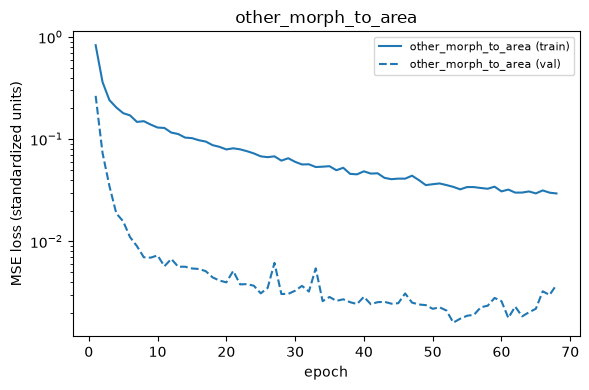

,R2,MAE
feature,,
area,0.998536,4.756666


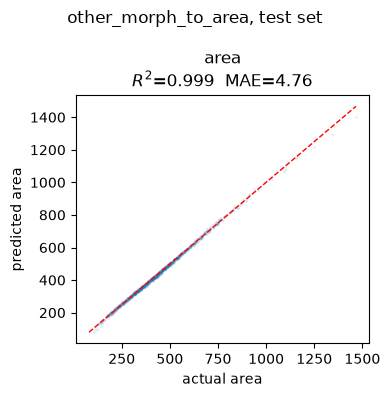

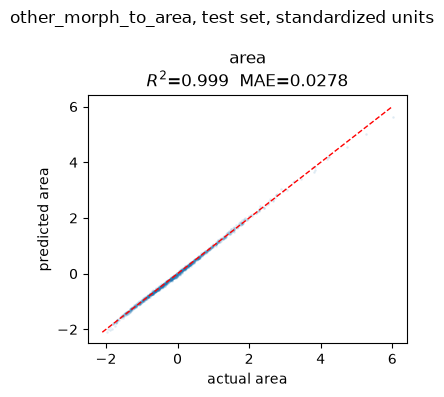

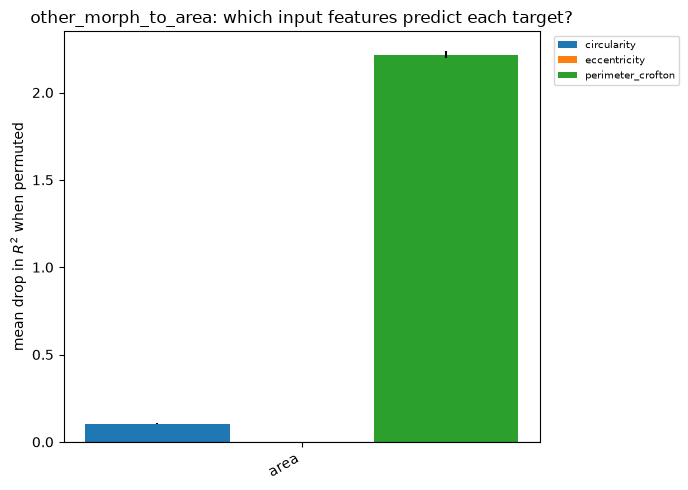


=== other_morph_to_perimeter_crofton: ['area', 'circularity', 'eccentricity'] -> ['perimeter_crofton'] ===


other_morph_to_perimeter_crofton:   0%|          | 0/150 [00:00<?, ?it/s]

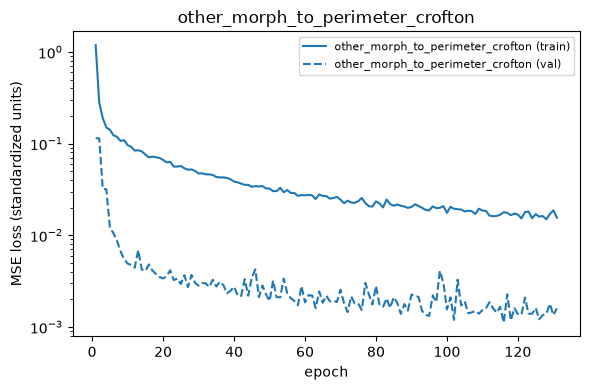

,R2,MAE
feature,,
perimeter_crofton,0.998887,0.347149


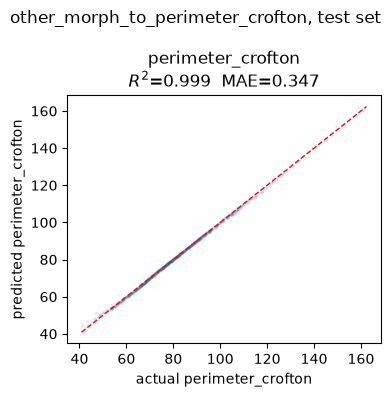

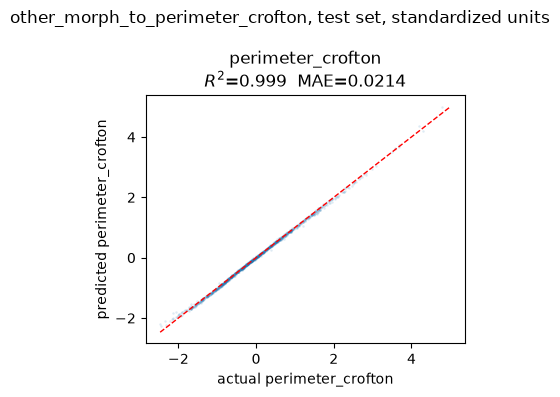

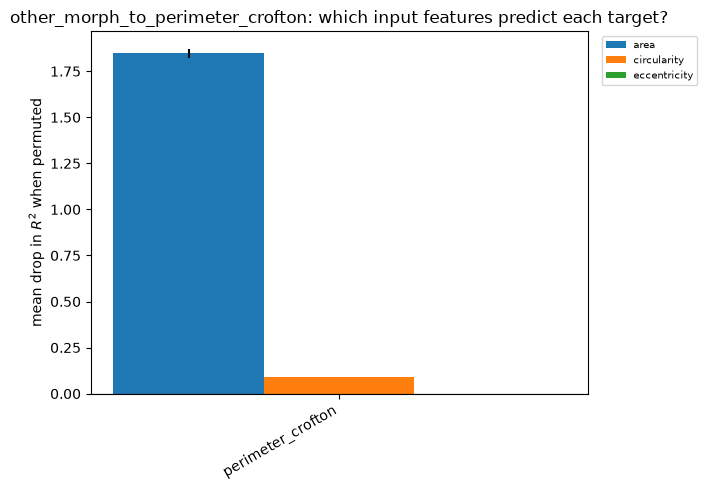


=== other_morph_to_circularity: ['area', 'perimeter_crofton', 'eccentricity'] -> ['circularity'] ===


other_morph_to_circularity:   0%|          | 0/150 [00:00<?, ?it/s]

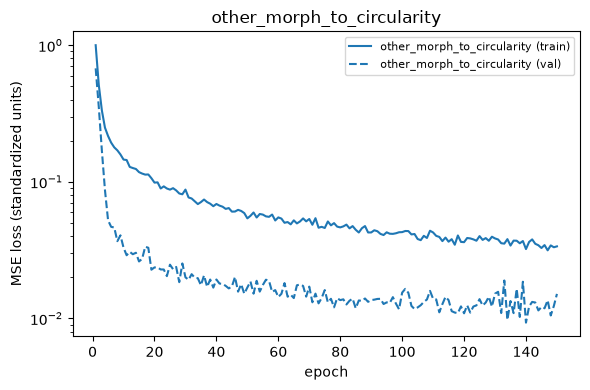

,R2,MAE
feature,,
circularity,0.99095,0.003951


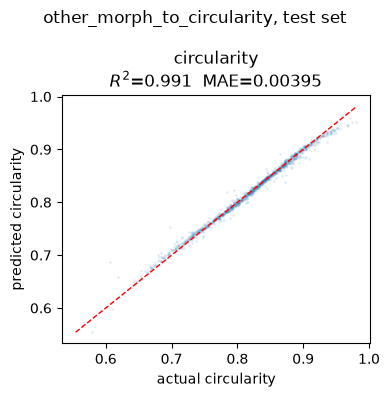

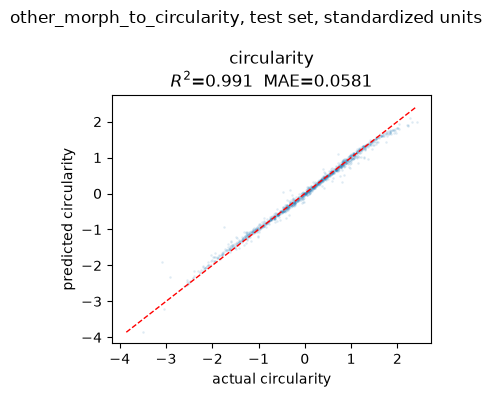

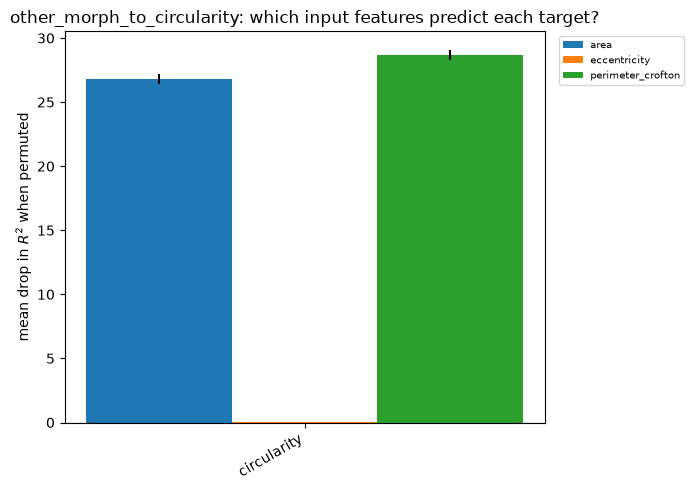


=== other_morph_to_eccentricity: ['area', 'perimeter_crofton', 'circularity'] -> ['eccentricity'] ===


other_morph_to_eccentricity:   0%|          | 0/150 [00:00<?, ?it/s]

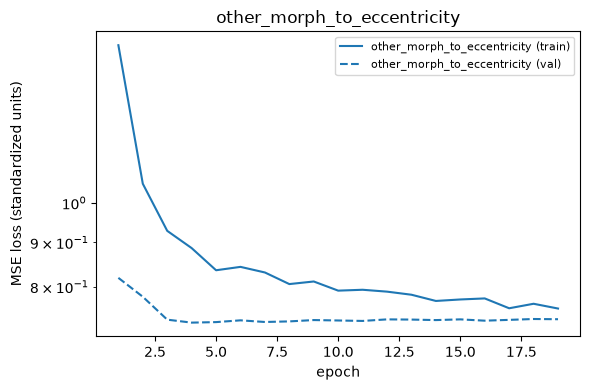

,R2,MAE
feature,,
eccentricity,0.25619,0.094798


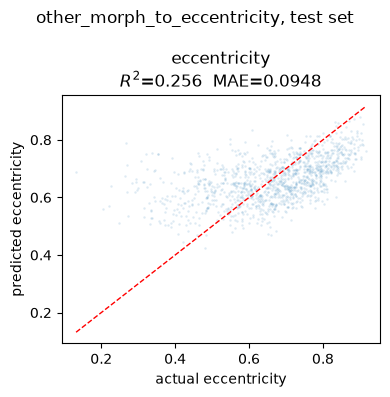

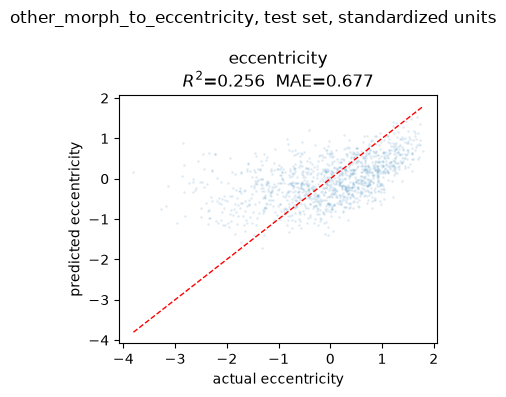

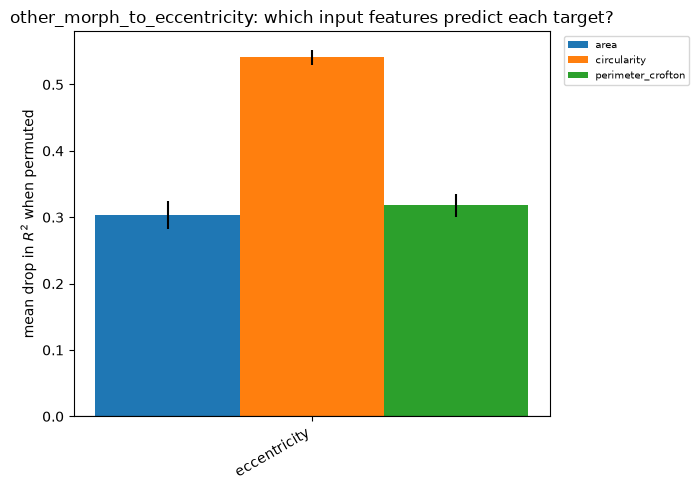

In [11]:
results = {
    name: run_tabular_experiment(
        name, cfg['x_cols'], cfg['y_cols'],
        **{k: v for k, v in cfg.items() if k not in ('x_cols', 'y_cols')},
    )
    for name, cfg in EXPERIMENTS.items()
}

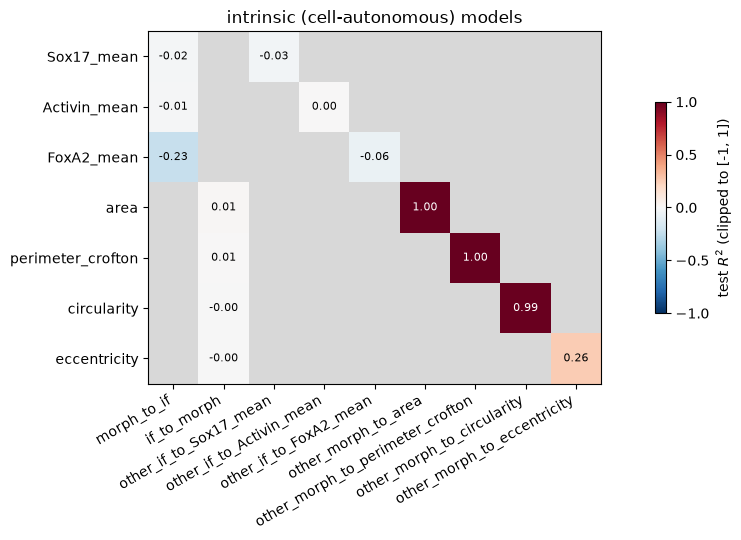

experiment,morph_to_if,if_to_morph,other_if_to_Sox17_mean,other_if_to_Activin_mean,other_if_to_FoxA2_mean,other_morph_to_area,other_morph_to_perimeter_crofton,other_morph_to_circularity,other_morph_to_eccentricity
target,,,,,,,,,
Sox17_mean,-0.017711,NaN,-0.026878,NaN,NaN,NaN,NaN,NaN,NaN
Activin_mean,-0.008663,NaN,NaN,0.003689,NaN,NaN,NaN,NaN,NaN
FoxA2_mean,-0.232717,NaN,NaN,NaN,-0.064986,NaN,NaN,NaN,NaN
area,NaN,0.011709,NaN,NaN,NaN,0.998536,NaN,NaN,NaN
perimeter_crofton,NaN,0.007597,NaN,NaN,NaN,NaN,0.998887,NaN,NaN
circularity,NaN,-0.003372,NaN,NaN,NaN,NaN,NaN,0.99095,NaN
eccentricity,NaN,-0.000773,NaN,NaN,NaN,NaN,NaN,NaN,0.25619


In [12]:
target_cols_by_experiment = {name: cfg['y_cols'] for name, cfg in EXPERIMENTS.items()}
summary = plot_experiment_comparison(
    results, target_cols_by_experiment, title='intrinsic (cell-autonomous) models'
)
display(summary)

### Feature correlations (fast, training-free)

Pairwise Pearson correlation across every morphology + IF feature -- a quick sanity check on
which features move together (or apart) that doesn't require training anything. Complements
the leave-one-out experiments above: correlation only catches *linear* relationships, while
the leave-one-out models can pick up nonlinear redundancy too.


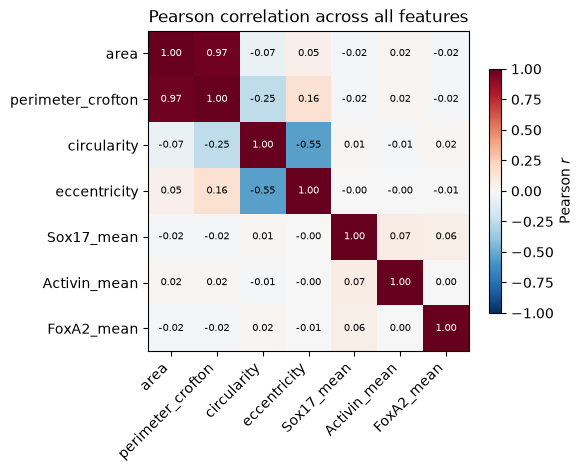

,feature_1,feature_2,r
0,area,perimeter_crofton,0.971778
1,circularity,eccentricity,-0.546813
2,perimeter_crofton,circularity,-0.253885
3,perimeter_crofton,eccentricity,0.156223
4,Sox17_mean,Activin_mean,0.073816
5,area,circularity,-0.069143
6,Sox17_mean,FoxA2_mean,0.060182
7,area,eccentricity,0.054484
8,perimeter_crofton,Activin_mean,0.023154
9,perimeter_crofton,FoxA2_mean,-0.021284


In [13]:
fig, corr = plot_correlation_heatmap(
    cell_df, morphology_cols + if_cols, title='Pearson correlation across all features'
)
plt.show()

display(top_correlated_pairs(corr, n=15))


## Next steps

- The real comparison this notebook sets up: run `extrinsic.ipynb` on the same targets and
  compare test $R^2$. If neighbor-only models do comparably well, that's evidence for
  non-cell-autonomous (community/paracrine) effects rather than a purely cell-intrinsic
  coupling between fate and shape.
- The `other_if_to_*` leave-one-out runs test redundancy between markers directly (e.g. if
  `other_if_to_T_mean` has high $R^2$, `T_mean` is largely predictable from `HAND1_mean`/
  `BMP4_mean` alone). Uncomment the morphology leave-one-out block to check the same thing
  for shape features (`area` vs. `equivalent_diameter` are a likely redundant pair). The
  correlation heatmap above gives the same kind of answer instantly, but only for linear
  relationships -- a feature pair can be redundant (high leave-one-out $R^2$) without being
  linearly correlated, and vice versa.
- Try `EXCLUDE_HOECHST = False` to see whether nuclear DNA content adds anything once
  cell-cycle-correlated size effects are in play.
- This is observational/correlational -- it tells you which features move together, not
  that one causes the other. The optogenetic perturbation gives you an experimental handle
  on that (e.g. compare these relationships in activated vs. non-activated regions, or
  before/after activation) once that metadata is attached to `cell_df`.
